<a href="https://colab.research.google.com/github/opendatas2017/NMC/blob/main/NMCourse_numpy_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Введение NumPy


Документация https://numpy.org/doc/

### Основная информация и особенности


NumPy — это фундаментальная библиотека Python для научных вычислений, известная как Numerical Python, которая предоставляет мощные инструменты для работы с многомерными массивами и математическими операциями.
Библиотека оптимизирована для быстрых вычислений с большими объемами числовых данных благодаря реализации на C и Fortran, что делает её в десятки раз быстрее стандартных списков Python. Она лежит в основе многих других библиотек вроде Pandas, SciPy и TensorFlow, став стандартом де-факто для Data Science и машинного обучения


**N-мерные массивы (ndarray)**  
Основная структура данных — однородные массивы произвольной размерности с поддержкой векторизации (операции над всем массивом без циклов), что упрощает код и ускоряет выполнение.

**Математические функции**  
Встроенные инструменты для линейной алгебры (`np.linalg`), преобразований Фурье (`np.fft`), генерации случайных чисел (`np.random`) и базовых операций (сумма, среднее, статистика).

**Индексация и срезы**  
Продвинутая индексация (булева, fancy indexing), broadcasting (автоматическое расширение массивов для операций разной формы).


### Несколько интересных фактов о NumPy

- **«Под капотом» он не совсем Python**: Для ускорения работы ресурсоемких операций NumPy реализован на языках программирования **C**, **C++** и **Fortran**, что обеспечивает значительное повышение производительности по сравнению со стандартными списками Python.

- **Основа всего**: NumPy лежит в основе экосистемы Data Science в Python. Без неё невозможна работа многих известных библиотек, включая **Pandas**, **Scikit-learn**, **SciPy** и **Matplotlib**.

- **«Магические» константы и функции**: Помимо массивов, NumPy предоставляет доступ к математическим константам (например, **np.e**, **np.pi**) и мощным функциям, которые обрабатывают целые массивы одновременно («векторизация»).


- **Умное индексирование и срезы**: Поддерживаются гибкие методы выборки элементов массива, например, конструкцию типа `arr[arr > 0]`, возвращающую только положительные значения, или `arr[[0, 2, 4]]`, выбирающую конкретные индексы.

- **Матрицы vs поэлементные операции**: Оператор `*` выполняет поэлементное умножение, оператор `@` или функция `np.dot()` осуществляет матричное умножение. Различие часто сбивает с толку новичков, но существенно упрощает работу с большими объемами данных.

- **Создан под влиянием MATLAB**: Библиотека создана под сильным влиянием **MATLAB**, что отражено в её синтаксисе и функциях.

- **Экономия памяти (Broadcasting)**: NumPy поддерживает механизм **broadcasting**, позволяющий выполнять операции над массивами разных форматов без создания временных копий данных, обеспечивая значительную экономию памяти.


Представьте: вместо медленных циклов по спискам мы получим молниеносные массивы, которые ускоряют код в 50-100 раз! 🚀

### Часть 1: Введение в NumPy

Установка, импорт и сравнение со списками Python. Создание первых массивов (np.array, np.zeros, np.ones, np.arange, np.linspace). Атрибуты массивов (shape, dtype, ndim, size).

💡 Совет: Используйте  Google Colab — там NumPy уже установлен!

In [ ]:
# Самый простой способ — через pip
### pip install numpy

# Или через conda (если используете Anaconda)
###  conda install numpy


Проверка установки:

In [ ]:
import numpy as np

import timeit
print("Numpy version is ",np.__version__)  # Должно показать версию, например 2.0.2


Numpy version is  2.0.2


Почему не списки Python ?

In [ ]:
SIZE: int = 2_000_000
# Сравним скорость: список vs массив с timeit
print(f"🏎️  БЕНЧМАРК: Список vs NumPy ({SIZE} элементов)")

# 1. Сначала NumPy (быстрый)
arr_data = np.arange(SIZE)
def numpy_sum() -> np.float64:
    return np.sum(arr_data * 2)

arr_time = timeit.timeit(numpy_sum, number=100)
print(f"NumPy:      {arr_time:.3f} сек")

# 2. Python список (медленный)
list_data = list(range(SIZE))
def list_sum() -> float:
    return sum(x ** 2 for x in list_data)

list_time = timeit.timeit(list_sum, number=100)
print(f"Список:     {list_time:.3f} сек (×{list_time/arr_time:.0f} медленнее)")

print(f"\n🚀 NumPy {list_time/arr_time:.0f} раз быстрее!")


🏎️  БЕНЧМАРК: Список vs NumPy (2000000 элементов)
NumPy:      0.202 сек
Список:     12.356 сек (×61 медленнее)

🚀 NumPy 61 раз быстрее!


Первые  массивы

Рассмотрим как создаются  массивы

In [ ]:
# 🔥 ОСНОВНОЙ КОНСТРУКТОР: из списка Python
arr1 = np.array([1, 2, 3, 4])
print(f"Массив из списка: {arr1}")

# Массивы нулей и единиц (полезно для инициализации)
zeros = np.zeros(5)
print(f"Массив нулей:     {zeros}")

ones = np.ones((2, 3))   # Матрица 2x3 из единиц
print(f"Матрица единиц:\n{ones}")

# Последовательности
arange = np.arange(0, 10, 2)  # [0, 2, 4, 6, 8] (шаг 2)
print(f"Arange (шаг 2):   {arange}")

linspace = np.linspace(0, 1, 5)  # 5 чисел от 0 до 1 включительно
print(f"Linspace (5 шт):  {linspace}")

# Важно: параметр endpoint
array_endinclude = np.linspace(0, 10, num=5, endpoint=True)  # включая 10
array_endexclude = np.linspace(0, 10, num=5, endpoint=False) # исключая 10
print(f"Linspace (вкл 10): {array_endinclude}")
print(f"Linspace (искл 10):{array_endexclude}")

Массив из списка: [1 2 3 4]
Массив нулей:     [0. 0. 0. 0. 0.]
Матрица единиц:
[[1. 1. 1.]
 [1. 1. 1.]]
Arange (шаг 2):   [0 2 4 6 8]
Linspace (5 шт):  [0.   0.25 0.5  0.75 1.  ]
Linspace (вкл 10): [ 0.   2.5  5.   7.5 10. ]
Linspace (искл 10):[0. 2. 4. 6. 8.]


Функция np.empty_like() в NumPy используется для создания нового массива NumPy с той же формой (shape) и типом данных (dtype), что и существующий массив или объект, похожий на массив.

Однако, в отличие от np.empty(), она не инициализирует элементы нового массива — они остаются со случайными (произвольными) значениями (возможно, это то, что уже находилось в этой области памяти).

In [ ]:
# np.empty создает массив без инициализации (там мусор из памяти)
# Используется для скорости, если вы сразу перезапишете значения
num_array = np.empty((2, 3))
print(f"Пустой массив (мусор):\n{num_array}")
print(f"Тип объекта: {type(num_array)}\n")

# Создание массивов на основе существующего (сохраняет shape и dtype)
num_array_src = np.array([[2, 0], [1, 2]])
arr_empty_like = np.empty_like(num_array_src)

print(f"Исходный массив:\n{num_array_src}")
print(f"Empty_like (форма {arr_empty_like.shape}, тип {arr_empty_like.dtype}):\n{arr_empty_like}\n")

# Другие полезные конструкторы
arr_zero_like = np.zeros_like(num_array_src)
print(f"Zeros_like:\n{arr_zero_like}")

arr_full = np.full((2, 3), 5) # Массив заполненный пятерками
print(f"Full (5):\n{arr_full}")

Пустой массив (мусор):
[[1. 1. 1.]
 [1. 1. 1.]]
Тип объекта: <class 'numpy.ndarray'>

Исходный массив:
[[2 0]
 [1 2]]
Empty_like (форма (2, 2), тип int64):
[[4611686018427387904 4616189618054758400]
 [4618441417868443648 4620693217682128896]]

Zeros_like:
[[0 0]
 [0 0]]
Full (5):
[[5 5 5]
 [5 5 5]]


Анатомия векторов и массивов

In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6]])
float_arr = np.array([[1., 2., 3.], [4., 5., 6.]])

print(f"Массив:\n{arr}\n")

# 📏 shape — размерность (строки, столбцы)
print(f"Shape (форма):    {arr.shape}")

# 🔢 dtype — тип данных элементов
print(f"Dtype (тип):      {arr.dtype} | {float_arr.dtype}")

# 📐 ndim — количество измерений (осей)
print(f"Ndim (измерения): {arr.ndim}")

# 📊 size — общее количество элементов
print(f"Size (элементов): {arr.size}")

# 📊 Itemsize — размер одного элемента в байтах
print(f"Itemsize (байт):  {arr.itemsize}")

# 📏 Nbytes — общий размер массива в памяти
print(f"Nbytes (всего):   {arr.nbytes}")

Массив:
[[1 2 3]
 [4 5 6]]

Shape (форма):    (2, 3)
Dtype (тип):      int64 | float64
Ndim (измерения): 2
Size (элементов): 6
Itemsize (байт):  8
Nbytes (всего):   48


Используем случайные значения

In [ ]:
# Генерация случайных чисел (равномерное распределение [0, 1))
random_number1 = np.random.random()
print(f"Случайное число (random): {random_number1}")

random_number2 = np.random.rand()
print(f"Случайное число (rand):   {random_number2}")

# Массивы со случайными значениями
arr_random1 = np.random.random((2, 3))
print(f"\nМассив random (2x3):\n{arr_random1}")

arr_random2 = np.random.rand(2, 3)
print(f"\nМассив rand (2x3):\n{arr_random2}")

Случайное число (random): 0.9778601656892829
Случайное число (rand):   0.5113064553579636

Массив random (2x3):
[[0.88390872 0.30420265 0.54221766]
 [0.90648006 0.82098261 0.08057788]]

Массив rand (2x3):
[[0.75913028 0.50401198 0.9904207 ]
 [0.13728173 0.11419376 0.81808551]]


🔐 np.random.seed() — "Секрет воспроизводимости" в NumPy

Представьте генератор случайных чисел как огромную книгу с бесконечными страницами случайных чисел. np.random.seed() — это закладка, которая говорит: "Начинай всегда с этой страницы!"

In [ ]:
# Фиксация генератора случайных чисел для воспроизводимости результатов
np.random.seed(0)
arr_random_1 = np.random.rand(2, 1)
print(f"Первая генерация (seed=0):\n{arr_random_1}")

np.random.seed(0) # Сбрасываем seed в то же значение
arr_random_2 = np.random.rand(2, 1)
print(f"Вторая генерация (seed=0):\n{arr_random_2}")

print("\n💡 Результаты идентичны, так как seed одинаковый!")

Первая генерация (seed=0):
[[0.5488135 ]
 [0.71518937]]
Вторая генерация (seed=0):
[[0.5488135 ]
 [0.71518937]]

💡 Результаты идентичны, так как seed одинаковый!


In [ ]:
import numpy as np

# --- Создание массивов ---
# Матрица 3x3, заполненная единицами.
# Часто используется для инициализации весов или единичных матриц.
matrix = np.ones((3, 3))
print("Пример 1: Матрица 3x3 из единиц")
print(matrix)

# --- Атрибуты массива ---
# linspace создает массив из 11 равноотстоящих точек от 0 до 10.
arr = np.linspace(0, 10, 11)

print(f"\nПример 2: Атрибуты массива linspace(0, 10, 11)")
print(f"Массив: {arr}")
# shape: размеры массива, dtype: тип данных, ndim: количество измерений, size: общее число элементов
print(f"Shape: {arr.shape}, Dtype: {arr.dtype}, Ndim: {arr.ndim}, Size: {arr.size}")

# --- Сравнение производительности (Timeit) ---
# Подготовка данных для тестов
big_list = list(range(100000))       # Стандартный список Python
big_arr = np.arange(100000)          # Массив NumPy

print("\nПример 3: Сравнение скорости суммирования (100 000 элементов)")
# используем timeit

t_list = timeit.timeit(lambda: sum(big_list), number=1000)
t_np = timeit.timeit(lambda: np.sum(big_arr), number=1000)

print(f"\n✅ Сравнение скорости (сумма)")
print(f"Список Python: {t_list:.4f} сек")
print(f"NumPy массив:  {t_np:.4f} сек")

Пример 1: Матрица 3x3 из единиц
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

Пример 2: Атрибуты массива linspace(0, 10, 11)
Массив: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Shape: (11,), Dtype: float64, Ndim: 1, Size: 11

Пример 3: Сравнение скорости суммирования (100 000 элементов)

✅ Сравнение скорости (сумма)
Список Python: 0.7721 сек
NumPy массив:  0.0225 сек


### Python List vs NumPy Array
В Colab и Jupyter используем магическую команду `%timeit`. Она автоматически запускает код несколько раз для получения статистики.

In [ ]:
# %%timeit - магическая команда Jupyter/Colab для замера времени
# Запускаем сумму элементов списка Python
%timeit sum(big_list)

# Запускаем сумму элементов массива NumPy

%timeit np.sum(big_arr)

767 µs ± 1.67 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
22.5 µs ± 1.1 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


<div class="alert alert-success" role="alert" style="border-left: 5px solid #28a745; padding: 15px; margin: 10px 0;">
  <h3>🎯 <b>Ключевые выводы </b></h3>
  <ul style="font-size: 16px; line-height: 1.6;">
    <li><b><code>import numpy as np</code></b> — всегда так! 📥</li>
    <li><b>Массивы ≠ списки:</b> NumPy = скорость + векторизация ⚡</li>
    <li><b><code>np.array()</code></b> — основной инструмент создания 🛠️</li>
    <li><b><code>shape, dtype, ndim, size</code></b> — проверяйте перед работой! 🔍</li>
  </ul>
</div>

<div class="alert alert-info" role="alert" style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 20px; margin: 10px 0;">
  <h4>💡 <b>Запомни !</b></h4>
  <p><code>np</code> — это твой лучший друг в численных методах и Data Science! 🚀</p>
</div>


### Часть 2: Основы работы с массивами
Индексация и срезы (одномерные и многомерные). Изменение формы (reshape, flatten, transpose). Типы данных (int, float, complex) и приведение типов (astype).

Научимся "доставать" данные из массивов и менять их форму. Это как научиться пользоваться метро — сначала пугает, потом без него никуда! 🚇

In [ ]:
# Создаем массив температур за неделю
temps = np.array([20, 22, 19, 25, 23, 21])
print(f"🌡️  Температуры за неделю: {temps}\n")

# 🔥 БАЗОВАЯ ИНДЕКСАЦИЯ
# Индексы начинаются с 0!
print(f"1-й день (индекс 0): {temps[0]}")
print(f"2-й день (индекс 1): {temps[1]}")
print(f"Последний день (индекс -1): {temps[-1]}")

# 🔥 СРЕЗЫ [start:stop:step]
# Важно: элемент по индексу stop НЕ включается!
print(f"\n📊 Срезы:")
print(f"Дни со 2-го по 4-й [1:4]: {temps[1:4]}")  # Индексы 1, 2, 3
print(f"Каждый 2-й день [::2]: {temps[::2]}")     # Шаг 2
print(f"В обратном порядке [::-1]: {temps[::-1]}") # Реверс

🌡️  Температуры за неделю: [20 22 19 25 23 21]

1-й день (индекс 0): 20
2-й день (индекс 1): 22
Последний день (индекс -1): 21

📊 Срезы:
Дни со 2-го по 4-й [1:4]: [22 19 25]
Каждый 2-й день [::2]: [20 19 23]
В обратном порядке [::-1]: [21 23 25 19 22 20]


In [ ]:
# Матрица оценок: строки = ученики, столбцы = предметы (Мат, Хим, Физ)
grades = np.array([
    [5, 4, 3],  # Иван
    [4, 5, 4],  # Мария
    [3, 4, 5]   # Петя
])
print(f"📚 Матрица оценок:\n{grades}\n")

# 🔥 ИНДЕКСИРОВАНИЕ: [строка, столбец]
print(f"Оценка Ивана по математике [0, 0]: {grades[0, 0]}")
print(f"Оценка Марии по физике [1, 2]: {grades[1, 2]}")

# 🔥 СРЕЗЫ ПО ОСЯМ
print(f"\n📊 Срезы матрицы:")
print(f"Все оценки Ивана (строка 0): {grades[0, :]}")
print(f"Все оценки по математике (столбец 0): {grades[:, 0]}")
print(f"Подматрица (ученики 2-3, предметы 2-3):\n{grades[1:3, 1:3]}")

📚 Матрица оценок:
[[5 4 3]
 [4 5 4]
 [3 4 5]]

Оценка Ивана по математике [0, 0]: 5
Оценка Марии по физике [1, 2]: 4

📊 Срезы матрицы:
Все оценки Ивана (строка 0): [5 4 3]
Все оценки по математике (столбец 0): [5 4 3]
Подматрица (ученики 2-3, предметы 2-3):
[[5 4]
 [4 5]]


In [ ]:
# Исходный вектор из 12 элементов
data = np.arange(12)
print(f"1️⃣  Исходный вектор (1D): {data}")
print(f"   Форма: {data.shape}\n")

# 🔥 RESHAPE — меняем форму (элементы не теряются!)
# 3 строки × 4 столбца = 12 элементов
matrix = data.reshape(3, 4)
print(f"2️⃣  Матрица 3x4 (Reshape):\n{matrix}")
print(f"   Форма: {matrix.shape}\n")

# 🔥 FLATTEN — сплющиваем обратно в 1D (возвращает КОПИЮ)
flat = matrix.flatten()
print(f"3️⃣  Сплющенный (flatten): {flat}")

# 🔥 RAVEL — сплющиваем (возвращает ПРЕДСТАВЛЕНИЕ/VIEW)
# Изменение ravel может изменить исходную матрицу!
ravelled = matrix.ravel()
print(f"   Сплющенный (ravel): {ravelled}\n")

# 🔥 TRANSPOSE — транспонирование (строки ↔ столбцы)
transposed = matrix.T  # или matrix.transpose()
print(f"4️⃣  Транспонированная матрица:\n{transposed}")
print(f"   Форма: {transposed.shape}")

1️⃣  Исходный вектор (1D): [ 0  1  2  3  4  5  6  7  8  9 10 11]
   Форма: (12,)

2️⃣  Матрица 3x4 (Reshape):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
   Форма: (3, 4)

3️⃣  Сплющенный (flatten): [ 0  1  2  3  4  5  6  7  8  9 10 11]
   Сплющенный (ravel): [ 0  1  2  3  4  5  6  7  8  9 10 11]

4️⃣  Транспонированная матрица:
[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
   Форма: (4, 3)


##  Базовые операции линейной алгебры
Модуль `np.linalg` содержит функции для решения систем уравнений, нахождения собственных значений и разложений.

In [ ]:
# Создадим квадратную матрицу 3x3 для алгебраических операций
A = np.array([
    [4, 2, 1],
    [1, 3, 2],
    [2, 1, 4]
], dtype=float)

b = np.array([1, 2, 3], dtype=float) # Вектор правой части

print(f"Матрица A:\n{A}\n")
print(f"Вектор b: {b}\n")

# 1. Транспонирование (уже видели, но важно в контексте алгебры)
print(f"1. Транспонированная A.T:\n{A.T}\n")

# 2. Определитель (Det)
# Если det(A) == 0, матрица вырожденная (обратной не существует)
det_A = np.linalg.det(A)
print(f"2. Определитель det(A): {det_A:.4f}\n")

# 3. Обратная матрица (Inverse)
# Используется для теоретического решения X = A^(-1) * b

try:
    A_inv = np.linalg.inv(A)
    print(f"3. Обратная матрица A^(-1):\n{A_inv}\n")
except np.linalg.LinAlgError:
    print("3. Матрица вырожденная, обратной не существует.\n")

# 4. Треугольные матрицы (Triangular)
# Часто используются в методах разложения (LU, Холецкого)
lower = np.tril(A, k = 0) # Lower (нижняя треугольная) k=0: Main diagonal (includes the diagonal) .
upper = np.triu(A) # Upper (верхняя треугольная)
print(f"4. Нижняя треугольная (tril):\n{lower}\n")
print(f"   Верхняя треугольная (triu):\n{upper}\n")

# --- k = 1 ---
# Сохраняется только то, что ВЫШЕ главной диагонали
# Главная диагональ обнуляется. Полезно для строго верхнетреугольных матриц.
upper_strict = np.triu(A, k=1)
print(f" Строго верхняя (k=1): Главная диагональ исключена\n{upper_strict}\n")

# 5. Умножение матриц и векторов
# Важно: используйте оператор @ для матричного умножения!
# Оператор * выполняет поэлементное умножение.
vec_result = A @ b        # Матрица на вектор
mat_result = A @ A.T      # Матрица на матрицу
elem_result = A * 2       # Каждую элемент на число

print(f"5. Умножение A @ b (вектор):\n{vec_result}")
print(f"   Умножение A @ A.T (матрица):\n{mat_result}")

diag = np.diag(A)
print(f"\n6. Гланая диагональ {diag}")
print(f"\n Диагональная матрица: \n {np.diag(diag)}")

Матрица A:
[[4. 2. 1.]
 [1. 3. 2.]
 [2. 1. 4.]]

Вектор b: [1. 2. 3.]

1. Транспонированная A.T:
[[4. 1. 2.]
 [2. 3. 1.]
 [1. 2. 4.]]

2. Определитель det(A): 35.0000

3. Обратная матрица A^(-1):
[[ 0.28571429 -0.2         0.02857143]
 [ 0.          0.4        -0.2       ]
 [-0.14285714  0.          0.28571429]]

4. Нижняя треугольная (tril):
[[4. 0. 0.]
 [1. 3. 0.]
 [2. 1. 4.]]

   Верхняя треугольная (triu):
[[4. 2. 1.]
 [0. 3. 2.]
 [0. 0. 4.]]

 Строго верхняя (k=1): Главная диагональ исключена
[[0. 2. 1.]
 [0. 0. 2.]
 [0. 0. 0.]]

5. Умножение A @ b (вектор):
[11. 13. 16.]
   Умножение A @ A.T (матрица):
[[21. 12. 14.]
 [12. 14. 13.]
 [14. 13. 21.]]

6. Гланая диагональ [4. 3. 4.]

 Диагональная матрица: 
 [[4. 0. 0.]
 [0. 3. 0.]
 [0. 0. 4.]]


Типы данных — "Как храним числа?"

In [ ]:
# NumPy строго типизирован (в отличие от списков Python)
int_arr = np.array([1, 2, 3], dtype=np.int32)      # 4 байта
float_arr = np.array([1.5, 2.3], dtype=np.float64) # 8 байт
complex_arr = np.array([1+2j, 3+4j])               # Комплексные числа

print(f"🔢 Типы данных:")
print(f"Целые (int32): {int_arr.dtype}")
print(f"Вещественные (float64): {float_arr.dtype}")
print(f"Комплексные: {complex_arr.dtype}\n")

# 🔥 ASTYPE — приведение типов
mixed = np.array([1, 2, 3.14])
print(f"Исходный массив (авто float64): {mixed.dtype}")

# Принудительное приведение к целому (дробная часть отбрасывается!)
ints_only = mixed.astype(np.int32)
print(f"Приведение к int32: {ints_only} → {ints_only.dtype}")

🔢 Типы данных:
Целые (int32): int32
Вещественные (float64): float64
Комплексные: complex128

Исходный массив (авто float64): float64
Приведение к int32: [1 2 3] → int32


In [ ]:
# Разные размеры целых чисел (экономия памяти)
arr_int8 = np.array([1, 2, 3], dtype='int8')    # 1 байт (-128 до 127)
arr_int64 = np.array([1, 2, 3], dtype='int64')  # 8 байт (огромные числа)

print(f"💾 Размер в памяти:")
print(f"int8:  {arr_int8.dtype} → {arr_int8.itemsize} байт/эл.")
print(f"int64: {arr_int64.dtype} → {arr_int64.itemsize} байт/эл.\n")

# ⚠️ Внимание: float128 может не поддерживаться на некоторых системах (например, Windows)
try:
    arr_float128 = np.array([1.5, 2.5], dtype='float128')
    print(f"float128: {arr_float128.dtype} → {arr_float128.itemsize} байт/эл.")
except Exception:
    print("⚠️  float128 не поддерживается на этой платформе")

💾 Размер в памяти:
int8:  int8 → 1 байт/эл.
int64: int64 → 8 байт/эл.

float128: float128 → 16 байт/эл.


<div class="alert alert-info" style="border-left: 6px solid #17a2b8; padding: 20px;">

### 📊 Основные типы данных в NumPy

| Тип данных | Описание | Примеры |
|------------|----------|---------|
| **`int`** | **Целые числа** | `int8`, `int16`, `int32`, `int64` |
| **`float`** | **Дробные числа** | `float32`, `float64` |
| **`complex`** | **Комплексные числа** | `complex64`, `complex128` |
| **`bool`** | **Логические значения** | `True`, `False` |
| **`str`** | **Строки** | `'текст'`, `'hello'` |
| **`object`** | **Любые Python объекты** | списки, словари, функции |

</div>


### Часть 3: Операции и Векторизация
Элементные операции (+, -, *, /, **). Универсальные функции (ufunc): np.sin, np.exp, np.log и логические операции.

Забудьте циклы for! Сегодня научимся делать математику над ВСЕМИ числами сразу — это называется векторизация! ⚡

Главное правило: + - * / ** работают ПО ЭЛЕМЕНТАМ (не матрично!)

In [ ]:
import numpy as np

# Температуры по дням недели
temps = np.array([20, 22, 19, 25, 23, 21, 18])
print(f"🌡️  Температуры за неделю: {temps}\n")

# 🔥 ВСЕ ОПЕРАЦИИ ВЫПОЛНЯЮТСЯ ПОЭЛЕМЕНТНО!
print("📊 Арифметические операции:")
print(f" +2°:        {temps + 2}")
print(f" -3°:         {temps - 3}")
print(f"Удвоить:           {temps * 2}")
print(f"Поделить на 2:     {temps / 2}")
print(f"В квадрате:        {temps ** 2}")
print(f"Остаток от деления на 5: {temps % 5}")
print(f"Целочисленное деление:  {temps // 5}\n")

# 🔥 УНИВЕРСАЛЬНЫЕ ФУНКЦИИ (ufunc)
print("📊 Математические функции:")
print(f"Корень:            {np.sqrt(temps)}")
print(f"Абсолютное значение: {np.abs(temps - 20)}")
print(f"Степень 10:        {np.power(temps, 2)}")

🌡️  Температуры за неделю: [20 22 19 25 23 21 18]

📊 Арифметические операции:
 +2°:        [22 24 21 27 25 23 20]
 -3°:         [17 19 16 22 20 18 15]
Удвоить:           [40 44 38 50 46 42 36]
Поделить на 2:     [10.  11.   9.5 12.5 11.5 10.5  9. ]
В квадрате:        [400 484 361 625 529 441 324]
Остаток от деления на 5: [0 2 4 0 3 1 3]
Целочисленное деление:  [4 4 3 5 4 4 3]

📊 Математические функции:
Корень:            [4.47213595 4.69041576 4.35889894 5.         4.79583152 4.58257569
 4.24264069]
Абсолютное значение: [0 2 1 5 3 1 2]
Степень 10:        [400 484 361 625 529 441 324]


In [ ]:
# Матрица оценок: строки = ученики, столбцы = предметы
grades_math = np.array([[5, 4, 3],   # Иван
                        [4, 5, 4],   # Мария
                        [3, 4, 5]])  # Петя

grades_phys = np.array([[4, 3, 4],
                        [5, 4, 5],
                        [4, 5, 4]])

print("📚 Оценки по математике:\n", grades_math)
print("\n📚 Оценки по физике:\n", grades_phys)

print("\n📊 Операции между массивами:")
print(f"Сумма (матем + физ):\n{grades_math + grades_phys}")
print(f"\nРазница (матем - физ):\n{grades_math - grades_phys}")
print(f"\nПроизведение (поэлементно!):\n{grades_math * grades_phys}")
print(f"\nДеление:\n{grades_math / grades_phys}")

# ⚠️ ВАЖНО: * это поэлементное умножение, НЕ матричное!
# Для матричного умножения используйте @ или np.dot()

📚 Оценки по математике:
 [[5 4 3]
 [4 5 4]
 [3 4 5]]

📚 Оценки по физике:
 [[4 3 4]
 [5 4 5]
 [4 5 4]]

📊 Операции между массивами:
Сумма (матем + физ):
[[9 7 7]
 [9 9 9]
 [7 9 9]]

Разница (матем - физ):
[[ 1  1 -1]
 [-1  1 -1]
 [-1 -1  1]]

Произведение (поэлементно!):
[[20 12 12]
 [20 20 20]
 [12 20 20]]

Деление:
[[1.25       1.33333333 0.75      ]
 [0.8        1.25       0.8       ]
 [0.75       0.8        1.25      ]]


In [ ]:
arr1 = np.array([10, 20, 30, 40])
arr2 = np.array([30, 40, 50, 60])
print("Массив 1:", arr1)
print("Массив 2:", arr2)

# setdiff1d()
intersection = np.intersect1d(arr1, arr2)
print("Пересечение:", intersection)


Массив 1: [10 20 30 40]
Массив 2: [30 40 50 60]
Пересечение: [30 40]


In [ ]:
# Оценки студентов
grades = np.array([5, 4, 3, 5, 2, 5, 4, 3, 5, 4])
print(f"📊 Оценки: {grades}\n")

# 🔥 ЛОГИЧЕСКИЕ ОПЕРАЦИИ ВОЗВРАЩАЮТ БУЛЕВЫ МАСКИ
print("📊 Логические операции:")
print(f"Оценка > 3:     {grades > 3}")
print(f"Оценка >= 4:    {grades >= 4}")
print(f"Оценка == 5:    {grades == 5}")
print(f"Оценка != 5:    {grades != 5}\n")

# 🔥 ФИЛЬТРАЦИЯ ЧЕРЕЗ БУЛЕВУ МАСКУ
print("📊 Фильтрация данных:")
excellent = grades[grades == 5]
print(f"Отличники (5):      {excellent}")

good = grades[grades >= 4]
print(f"Хорошисты (≥4):     {good}")

bad = grades[grades < 3]
print(f"Двоечники (<3):     {bad}\n")

# 🔥 СЛОЖНЫЕ УСЛОВИЯ (И, ИЛИ)
# Важно: используем & (И) и | (ИЛИ), а не and/or!
print("📊 Сложные условия:")
print(f"4 или 5:           {grades[(grades == 4) | (grades == 5)]}")
print(f"От 3 до 5:         {grades[(grades >= 3) & (grades <= 5)]}")

📊 Оценки: [5 4 3 5 2 5 4 3 5 4]

📊 Логические операции:
Оценка > 3:     [ True  True False  True False  True  True False  True  True]
Оценка >= 4:    [ True  True False  True False  True  True False  True  True]
Оценка == 5:    [ True False False  True False  True False False  True False]
Оценка != 5:    [False  True  True False  True False  True  True False  True]

📊 Фильтрация данных:
Отличники (5):      [5 5 5 5]
Хорошисты (≥4):     [5 4 5 5 4 5 4]
Двоечники (<3):     [2]

📊 Сложные условия:
4 или 5:           [5 4 5 5 4 5 4]
От 3 до 5:         [5 4 3 5 5 4 3 5 4]


In [ ]:
unsorted_array = np.array([10, 50, 20, 40, 30])
print("Исходный  массив :\n", unsorted_array)

# sort()
sorted_array = np.sort(unsorted_array)
print("Sorted массив:\n", sorted_array)

Исходный  массив :
 [10 50 20 40 30]
Sorted массив:
 [10 20 30 40 50]


In [ ]:
# Исходные данные
scores = np.array([85, 92, 78, 95, 60, 88, 72, 91])
print(f"📊 Баллы студентов: {scores}\n")

# 🔥 WHERE: условие, значение_если_True, значение_если_False
passed = np.where(scores >= 75, "Зачёт", "Незачёт")
print(f"Результат: {passed}")

# 🔥 Числовая замена
grades_converted = np.where(scores >= 90, 5,
                     np.where(scores >= 75, 4,
                     np.where(scores >= 60, 3, 2)))
print(f"Оценки:    {grades_converted}")

# 🔥 Поиск индексов
high_scorers = np.where(scores >= 90)

print(f"\nИндексы отличников: {high_scorers[0]}")
print(f"Баллы отличников:   {scores[high_scorers]}")

📊 Баллы студентов: [85 92 78 95 60 88 72 91]

Результат: ['Зачёт' 'Зачёт' 'Зачёт' 'Зачёт' 'Незачёт' 'Зачёт' 'Незачёт' 'Зачёт']
Оценки:    [4 5 4 5 3 4 3 5]

Индексы отличников: [1 3 7]
Баллы отличников:   [92 95 91]


Явная индексация

In [ ]:
arr = np.array([100, 200, 300, 400, 500])
print("Исходный массив", arr)
indices = np.array([1, 3, 4]) # индексы

selected_elements = arr[indices]
print("Выбранные элементы:",selected_elements)

Исходный массив [100 200 300 400 500]
Выбранные элементы: [200 400 500]


Копирование и представления

In [ ]:
import numpy as np

print("📋 ТЕМА: Копирование vs Представление (Copy vs View)\n")

# ═══════════════════════════════════════════════════════════════
# 1️⃣  ПОЛНАЯ КОПИЯ (.copy()) — независимый массив
# ═══════════════════════════════════════════════════════════════
print("═" * 60)
print("1️⃣  ПОЛНАЯ КОПИЯ — .copy()")
print("═" * 60)

original_array = np.array([10, 20, 30, 40, 50])
print(f"🔹 Исходный массив:  {original_array}")

# Создаём ПОЛНУЮ копию (новые данные в новой памяти)
array_copy = original_array.copy()
print(f"🔹 Создали копию:    {array_copy}")

# Изменяем копию
print(f"\n✏️  Изменяем копию: array_copy[0] = 999")
array_copy[0] = 999

print(f"🔸 Изменённая копия: {array_copy}")
print(f"🔹 Исходный массив:  {original_array} (не изменился!)\n")

print("✅ Вывод: .copy() создаёт независимую копию данных")
print("   Изменение копии НЕ влияет на исходный массив\n")

# ═══════════════════════════════════════════════════════════════
# 2️⃣  ПРЕДСТАВЛЕНИЕ (.view()) — тот же массив, другой вид
# ═══════════════════════════════════════════════════════════════
print("═" * 60)
print("2️⃣  ПРЕДСТАВЛЕНИЕ — .view()")
print("═" * 60)

original_array2 = np.array([10, 20, 30, 40, 50])
print(f"🔹 Исходный массив:  {original_array2}")

# Создаём ПРЕДСТАВЛЕНИЕ (те же данные, новая переменная)
array_view = original_array2.view()
print(f"🔹 Создали view:     {array_view}")

# Проверяем, делят ли они память
print(f"\n🔍 Делят ли память? {np.shares_memory(original_array2, array_view)}")

# Изменяем представление
print(f"\n✏️  Изменяем view: array_view[0] = 999")
array_view[0] = 999

print(f"🔸 Изменённый view:  {array_view}")
print(f"🔹 Исходный массив:  {original_array2} (ИЗМЕНИЛСЯ!)\n")

print("⚠️  Вывод: .view() создаёт представление тех же данных")
print("   Изменение view ВЛИЯЕТ на исходный массив\n")

# ═══════════════════════════════════════════════════════════════
# 3️⃣  СРАВНЕНИЕ В ТАБЛИЦЕ
# ═══════════════════════════════════════════════════════════════
print("═" * 60)
print("📊 СРАВНЕНИЕ: .copy() vs .view()")
print("═" * 60)

print("""
┌─────────────────┬──────────────────┬──────────────────┐
│   Характеристика│      .copy()     │      .view()     │
├─────────────────┼──────────────────┼──────────────────┤
│ Память          │ Новая (независ.) │ Та же (разделяют)│
│ Изменение       │ Не влияет        │ Влияет           │
│ Скорость        │ Медленнее        │ Быстрее          │
│ Использование   │ Безопасно        │ Требует осторож. │
└─────────────────┴──────────────────┴──────────────────┘
""")


📋 ТЕМА: Копирование vs Представление (Copy vs View)

════════════════════════════════════════════════════════════
1️⃣  ПОЛНАЯ КОПИЯ — .copy()
════════════════════════════════════════════════════════════
🔹 Исходный массив:  [10 20 30 40 50]
🔹 Создали копию:    [10 20 30 40 50]

✏️  Изменяем копию: array_copy[0] = 999
🔸 Изменённая копия: [999  20  30  40  50]
🔹 Исходный массив:  [10 20 30 40 50] (не изменился!)

✅ Вывод: .copy() создаёт независимую копию данных
   Изменение копии НЕ влияет на исходный массив

════════════════════════════════════════════════════════════
2️⃣  ПРЕДСТАВЛЕНИЕ — .view()
════════════════════════════════════════════════════════════
🔹 Исходный массив:  [10 20 30 40 50]
🔹 Создали view:     [10 20 30 40 50]

🔍 Делят ли память? True

✏️  Изменяем view: array_view[0] = 999
🔸 Изменённый view:  [999  20  30  40  50]
🔹 Исходный массив:  [999  20  30  40  50] (ИЗМЕНИЛСЯ!)

⚠️  Вывод: .view() создаёт представление тех же данных
   Изменение view ВЛИЯЕТ на исходный массив


Универсальные функции (ufunc) — "Математика в 1 строку"
ufunc = функции, которые работают со всем массивом сразу!

In [ ]:
# Углы в радианах
x = np.linspace(0, np.pi, 5)
print(f"📐 Углы (радианы): {x.round(2)}\n")

# 🔥 ТРИГОНОМЕТРИЧЕСКИЕ ФУНКЦИИ
print("📊 Тригонометрия:")
print(f"sin(x): {np.sin(x).round(3)}")
print(f"cos(x): {np.cos(x).round(3)}")
print(f"tan(x): {np.tan(x).round(3)}\n")

# 🔥 Экспоненты и логарифмы
print("📊 Экспоненты и логарифмы:")
print(f"exp(x):    {np.exp(x).round(3)}")
print(f"log(x+1):  {np.log(x + 1).round(3)}")
print(f"log10(x+1):{np.log10(x + 1).round(3)}\n")



📐 Углы (радианы): [0.   0.79 1.57 2.36 3.14]

📊 Тригонометрия:
sin(x): [0.    0.707 1.    0.707 0.   ]
cos(x): [ 1.     0.707  0.    -0.707 -1.   ]
tan(x): [ 0.00000000e+00  1.00000000e+00  1.63312394e+16 -1.00000000e+00
 -0.00000000e+00]

📊 Экспоненты и логарифмы:
exp(x):    [ 1.     2.193  4.81  10.551 23.141]
log(x+1):  [0.    0.58  0.944 1.211 1.421]
log10(x+1):[0.    0.252 0.41  0.526 0.617]



In [ ]:
# 🔥 Округление
print(x)
print("📊 Округление:")
print(f"Округлить:     {np.round(x, 1)}")
print(f"Пол (вниз):    {np.floor(x)}")
print(f"Потолок (вверх):{np.ceil(x)}")

[0.         0.78539816 1.57079633 2.35619449 3.14159265]
📊 Округление:
Округлить:     [0.  0.8 1.6 2.4 3.1]
Пол (вниз):    [0. 0. 1. 2. 3.]
Потолок (вверх):[0. 1. 2. 3. 4.]


Правила np.round() / round() в Python 3:

Округление до целого:

round(2.4) -> 2 (меньше 0.5, округляем вниз)

round(2.6) -> 3 (больше 0.5, округляем вверх)

round(2.5) -> 2 (половина к ближайшему четному)

round(3.5) -> 4 (половина к ближайшему четному)

Физика без циклов

In [ ]:
# 🚀  расчёт скорости и ускорения
time = np.array([1, 2, 3, 4, 5])           # секунды
distance = np.array([10, 18, 25, 30, 32])  # метры

print("🚀 ФИЗИКА БЕЗ ЦИКЛОВ\n")

# Скорость v = s/t (ВСЕ значения сразу!)
speed = distance / time
print(f"⏱️  Время (с):     {time}")
print(f"📏 Расстояние (м): {distance}")
print(f"🚀 Скорость (м/с): {speed.round(2)}\n")

# Ускорение a = Δv/Δt
acceleration = np.diff(speed) / np.diff(time)
print(f"📈 Ускорение (м/с²): {acceleration.round(2)}\n")

# Формула v = v₀ + at
v0 = 5.0      # начальная скорость
a = -0.5      # ускорение
v_final = v0 + a * time
print(f"📊 Формула v(t) = v₀ + at:")
print(f"   v₀ = {v0}, a = {a}")
print(f"   v(t) = {v_final}")

🚀 ФИЗИКА БЕЗ ЦИКЛОВ

⏱️  Время (с):     [1 2 3 4 5]
📏 Расстояние (м): [10 18 25 30 32]
🚀 Скорость (м/с): [10.    9.    8.33  7.5   6.4 ]

📈 Ускорение (м/с²): [-1.   -0.67 -0.83 -1.1 ]

📊 Формула v(t) = v₀ + at:
   v₀ = 5.0, a = -0.5
   v(t) = [4.5 4.  3.5 3.  2.5]


In [ ]:
# ❌ НЕПРАВИЛЬНО: циклы!
for i in range(5):
    temps[i] += 2

# ✅ ПРАВИЛЬНО: векторизация!
temps += 2  # ВСЕ ЭЛЕМЕНТЫ за 1 операцию!




### Часть 4: Статистические функции и агрегация
Сумма (sum), среднее (mean), стандартное отклонение (std), медиана (median). Операции по осям (axis=0/1). Кумулятивные суммы (cumsum) и произведения (cumprod).

In [ ]:
import numpy as np

print("📈 ТЕМА: Базовые статистические функции\n")

# Данные: оценки студентов за семестр
grades = np.array([5, 4, 3, 5, 2, 5, 4, 3, 5, 4, 3, 2, 5])
print(f"📚 Оценки студентов: {grades}\n")

print("🔹 Основные статистики:")
print(f"   ├─ Сумма:        {grades.sum():.0f}")
print(f"   ├─ Среднее:      {grades.mean():.2f}")
print(f"   ├─ Медиана:      {np.median(grades):.0f}")

# 🔥 ИСПРАВЛЕНИЕ: используем np.ptp() вместо grades.ptp()
print(f"   ├─ Стандартное отклонение: {grades.std():.2f}")
print(f"   ├─ Дисперсия:    {grades.var():.2f}")
print(f"   ├─ Минимум:      {grades.min()}")
print(f"   ├─ Максимум:     {grades.max()}")
print(f"   └─ Процентиль 75%: {np.percentile(grades, 75):.1f}\n")

📈 ТЕМА: Базовые статистические функции

📚 Оценки студентов: [5 4 3 5 2 5 4 3 5 4 3 2 5]

🔹 Основные статистики:
   ├─ Сумма:        50
   ├─ Среднее:      3.85
   ├─ Медиана:      4
   ├─ Стандартное отклонение: 1.10
   ├─ Дисперсия:    1.21
   ├─ Минимум:      2
   ├─ Максимум:     5
   └─ Процентиль 75%: 5.0



<div style="background: linear-gradient(90deg, #e3f2fd 0%, #bbdefb 100%);
            border-left: 6px solid #2196F3; padding: 25px; margin: 20px 0;
            border-radius: 10px; font-family: monospace;">

<h3>🔥 <b>Как работает axis=0 vs axis=1</b> 🎯</h3>




In [ ]:
import numpy as np

print("📊 ТЕМА: Работа с осями массивов\n")

# Матрица: строки = студенты, столбцы = предметы
grades_2d = np.array([
    [5, 4, 3],   # Иван
    [4, 5, 4],   # Мария
    [3, 4, 5],   # Пётр
    [5, 3, 4]    # Анна
])

print("📋 Оценки (студенты × предметы):")
print(grades_2d)
print("   Строки → студенты, Столбцы → предметы\n")

print("🔹 axis=0 → операция ПО СТОЛБЦАМ ↓ (по предметам):")
print(f"   Средний балл по математике: {grades_2d.mean(axis=0)[0]:.2f}")
print(f"   Средний балл по физике:     {grades_2d.mean(axis=0)[1]:.2f}")
print(f"   Средний балл по химии:      {grades_2d.mean(axis=0)[2]:.2f}")
print(f"   → Все сразу: {grades_2d.mean(axis=0)}\n")

print("🔹 axis=1 → операция ПО СТРОКАМ → (по студентам):")
print(f"   Средний балл Ивана:  {grades_2d.mean(axis=1)[0]:.2f}")
print(f"   Средний балл Марии:  {grades_2d.mean(axis=1)[1]:.2f}")
print(f"   Средний балл Петра:  {grades_2d.mean(axis=1)[2]:.2f}")
print(f"   Средний балл Анны:   {grades_2d.mean(axis=1)[3]:.2f}")
print(f"   → Все сразу: {grades_2d.mean(axis=1)}\n")

print("💡 ЗАПОМНИ: axis=0 — 'вертикально' (↓), axis=1 — 'горизонтально' (→)")

📊 ТЕМА: Работа с осями массивов

📋 Оценки (студенты × предметы):
[[5 4 3]
 [4 5 4]
 [3 4 5]
 [5 3 4]]
   Строки → студенты, Столбцы → предметы

🔹 axis=0 → операция ПО СТОЛБЦАМ ↓ (по предметам):
   Средний балл по математике: 4.25
   Средний балл по физике:     4.00
   Средний балл по химии:      4.00
   → Все сразу: [4.25 4.   4.  ]

🔹 axis=1 → операция ПО СТРОКАМ → (по студентам):
   Средний балл Ивана:  4.00
   Средний балл Марии:  4.33
   Средний балл Петра:  4.00
   Средний балл Анны:   4.00
   → Все сразу: [4.         4.33333333 4.         4.        ]

💡 ЗАПОМНИ: axis=0 — 'вертикально' (↓), axis=1 — 'горизонтально' (→)


In [ ]:
import numpy as np

print("📊 ТЕМА: Кумулятивные (накопительные) функции\n")

# Пример: ежедневные продажи магазина
daily_sales = np.array([100, 150, 80, 200, 120, 180, 90])
days = np.array(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])

print(f"📦 Ежедневные продажи: {daily_sales}")
print(f"📅 Дни:                {days}\n")

# 🔥 cumsum — накопительная сумма
cumulative = np.cumsum(daily_sales)
print("🔹 Накопительная сумма (выручка к концу дня):")
for day, daily, cum in zip(days, daily_sales, cumulative):
    print(f"   {day}: +{daily:3d} → всего: {cum:4d}")

print(f"\n🎯 Итоговая выручка за неделю: {cumulative[-1]} руб.\n")

# 🔥 cumprod — накопительное произведение (сложный процент)
print("🔹 Накопительное произведение (пример: рост вклада):")
interest = np.array([1.05, 1.03, 1.04, 1.02])  # коэффициенты роста
capital = 1000 * np.cumprod(interest)
print(f"   Начальный капитал: 1000 руб.")
for i, cap in enumerate(capital, 1):
    print(f"   После {i}-го периода: {cap:.2f} руб.")

📊 ТЕМА: Кумулятивные (накопительные) функции

📦 Ежедневные продажи: [100 150  80 200 120 180  90]
📅 Дни:                ['Пн' 'Вт' 'Ср' 'Чт' 'Пт' 'Сб' 'Вс']

🔹 Накопительная сумма (выручка к концу дня):
   Пн: +100 → всего:  100
   Вт: +150 → всего:  250
   Ср: + 80 → всего:  330
   Чт: +200 → всего:  530
   Пт: +120 → всего:  650
   Сб: +180 → всего:  830
   Вс: + 90 → всего:  920

🎯 Итоговая выручка за неделю: 920 руб.

🔹 Накопительное произведение (пример: рост вклада):
   Начальный капитал: 1000 руб.
   После 1-го периода: 1050.00 руб.
   После 2-го периода: 1081.50 руб.
   После 3-го периода: 1124.76 руб.
   После 4-го периода: 1147.26 руб.


# 🎯 Быстрая шпаргалка


| Функция   | Что делает     | Пример       |
|-----------|----------------|--------------|
| sum()     | Сумма          | 40           |
| mean()    | Среднее        | 4.0          |
| median()  | Медиана        | 4            |
| std()     | Разброс        | 0.94         |
| cumsum()  | Накопл.сумма   | [5, 9, 12]   |
| axis=0    | По столбцам ↓  | [4, 4.3, 4]  |

In [ ]:
import numpy as np

print("📊 ТЕМА: Поиск экстремумов и индексов\n")

# Данные: время забега на 100м (секунды)
times = np.array([12.5, 11.8, 13.2, 11.3, 12.1, 11.9])
athletes = ['Алексей', 'Борис', 'Виктор', 'Глеб', 'Дмитрий', 'Егор']

print(f"🏃 Результаты забега: {times} сек")
print(f"👥 Спортсмены:        {athletes}\n")

# 🔥 min/max + argmin/argmax
best_time = times.min()
best_idx = times.argmin()
print(f"🏆 Личный рекорд: {best_time} сек — {athletes[best_idx]}")

worst_time = times.max()
worst_idx = times.argmax()
print(f"🐢 Самое медленное: {worst_time} сек — {athletes[worst_idx]}\n")

# 🔥 Сортировка + argsort (индексы сортировки)
sorted_idx = np.argsort(times)  # индексы в порядке возрастания
print("📋 Рейтинг (быстрее → медленнее):")
for rank, idx in enumerate(sorted_idx, 1):
    print(f"   {rank}. {athletes[idx]:8s} — {times[idx]:.1f} сек")

📊 ТЕМА: Поиск экстремумов и индексов

🏃 Результаты забега: [12.5 11.8 13.2 11.3 12.1 11.9] сек
👥 Спортсмены:        ['Алексей', 'Борис', 'Виктор', 'Глеб', 'Дмитрий', 'Егор']

🏆 Личный рекорд: 11.3 сек — Глеб
🐢 Самое медленное: 13.2 сек — Виктор

📋 Рейтинг (быстрее → медленнее):
   1. Глеб     — 11.3 сек
   2. Борис    — 11.8 сек
   3. Егор     — 11.9 сек
   4. Дмитрий  — 12.1 сек
   5. Алексей  — 12.5 сек
   6. Виктор   — 13.2 сек


Что делать , если нужно векторизовать собственную функцию ?

In [ ]:
def my_custom(x:float ) -> float:
    if x > 0.5:
        return x ** 2
    else:
        return x

In [ ]:
vec_my_custom = np.vectorize(my_custom)  # Делаем векторной
test_arr = np.array([0.3, 0.6, 0.4, 0.7])
print(vec_my_custom(test_arr))  # [0.3  0.36 0.4  0.49]


[0.3  0.36 0.4  0.49]


In [ ]:
# 🔥 КАК ВЕКТОРИЗОВАТЬ СВОЮ ФУНКЦИЮ?

# Обычная функция (работает с одним числом)
def discount(price):
    """Скидка 10% если цена > 1000"""
    if price > 1000:
        return price * 0.9
    else:
        return price

# ❌ Не работает с массивом напрямую!
# prices = np.array([500, 1500, 800, 2000])
# discount(prices)  # ОШИБКА!

# ✅ Решение 1: np.vectorize (удобно)
vec_discount = np.vectorize(discount)
prices = np.array([500, 1500, 800, 2000])
print(f"💰 Цены:           {prices}")
print(f"💰 Со скидкой:     {vec_discount(prices)}\n")

# ✅ Решение 2: Булева индексация
def discount_fast(prices):
    result = prices.copy()
    mask = prices > 1000
    result[mask] = result[mask] * 0.9
    return result

print(f"💰 Со скидкой (2): {discount_fast(prices)}")


💰 Цены:           [ 500 1500  800 2000]
💰 Со скидкой:     [ 500 1350  800 1800]

💰 Со скидкой (2): [ 500 1350  800 1800]


Уникальные значения

In [ ]:
import numpy as np

print("📊 ТЕМА: Дополнительные полезные функции\n")

data = np.array([1, 2, 2, 3, 3, 3, 4, 5])
print(f"📊 Исходные данные: {data}\n")

# 🔹 unique — уникальные значения
unique_vals = np.unique(data)
print(f"🔹 Уникальные значения: {unique_vals}")

# 🔹 unique с подсчётом частот
vals, counts = np.unique(data, return_counts=True)
print(f"🔹 Частоты: {counts}\n")

# 🔹 any/all — логическая проверка
temps = np.array([22, 25, 28, 31, 29])
print(f"🌡️  Температуры: {temps}")
print(f"🔹 Есть ли выше 30°? {np.any(temps > 30)}")
print(f"🔹 Все ли выше 20°?  {np.all(temps > 20)}\n")

# 🔹 corrcoef — корреляция (связь между переменными)
height = np.array([170, 175, 180, 165, 172])
weight = np.array([65, 72, 78, 58, 68])
corr = np.corrcoef(height, weight)[0, 1]
print(f"📏 Рост:  {height}")
print(f"⚖️  Вес:   {weight}")
print(f"🔗 Корреляция: {corr:.3f} {'(сильная связь)' if abs(corr) > 0.7 else '(слабая связь)'}")

📊 ТЕМА: Дополнительные полезные функции

📊 Исходные данные: [1 2 2 3 3 3 4 5]

🔹 Уникальные значения: [1 2 3 4 5]
🔹 Частоты: [1 2 3 1 1]

🌡️  Температуры: [22 25 28 31 29]
🔹 Есть ли выше 30°? True
🔹 Все ли выше 20°?  True

📏 Рост:  [170 175 180 165 172]
⚖️  Вес:   [65 72 78 58 68]
🔗 Корреляция: 0.999 (сильная связь)


### Часть 5: Генерация случайных чисел и статистика
np.random: uniform, normal, randint. Монте-Карло методы. Корреляция (corrcoef) и ковариация. Бутстрэп для оценки погрешностей.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("🎲 ТЕМА: Генерация случайных чисел в NumPy\n")

# 🔐 Фиксируем "случайность" для воспроизводимости результатов
np.random.seed(42)  # 🎯 Всегда начинайте с этого в исследованиях!

print("=== Три основных распределения ===\n")

# 1️⃣ Равномерное распределение [0, 1)
uniform = np.random.rand(5)
print(f"📊 Uniform [0,1):  {uniform}")
print(f"   → Каждый результат равновероятен (лотерея)\n")

# 2️⃣ Нормальное распределение N(0, 1) — "колокол Гаусса"
normal = np.random.randn(5)
print(f"🔔 Normal N(0,1):   {normal}")
print(f"   → Рост людей, ошибки измерений, IQ\n")

# 3️⃣ Целые числа из заданного диапазона
integers = np.random.randint(1, 100, 5)
print(f"🎲 Целые [1,100):   {integers}")
print(f"   → Розыгрыши, выборка индексов\n")

# 🔁 Проверка воспроизводимости
print("✅ Проверка seed():")
np.random.seed(42)
a = np.random.rand(3)
np.random.seed(42)
b = np.random.rand(3)
print(f"   Два вызова с seed(42): {np.array_equal(a, b)}")  # True!

🎲 ТЕМА: Генерация случайных чисел в NumPy

=== Три основных распределения ===

📊 Uniform [0,1):  [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
   → Каждый результат равновероятен (лотерея)

🔔 Normal N(0,1):   [ 0.27904129  1.01051528 -0.58087813 -0.52516981 -0.57138017]
   → Рост людей, ошибки измерений, IQ

🎲 Целые [1,100):   [22 89 49 91 59]
   → Розыгрыши, выборка индексов

✅ Проверка seed():
   Два вызова с seed(42): True


Пример из жизни, реалистичные данные

📏 ПРИМЕР: Генерация антропометрических данных

👨 Мужчины:  среднее = 175.2 см, σ = 9.8 см
👩 Женщины:  среднее = 165.6 см, σ = 8.0 см



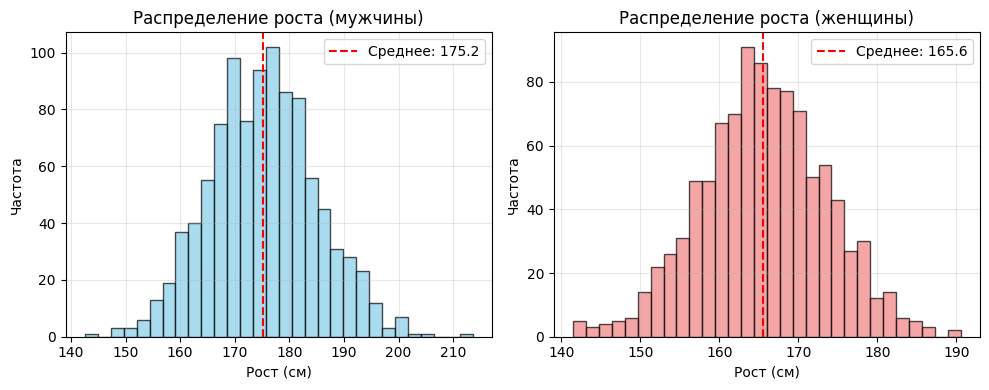

In [ ]:
print("📏 ПРИМЕР: Генерация антропометрических данных\n")

np.random.seed(42)

# 🚹 Рост мужчин: N(175 см, σ=10 см)
heights_m = np.random.normal(loc=175, scale=10, size=1000)

# 🚺 Рост женщин: N(165 см, σ=8 см)
heights_f = np.random.normal(loc=165, scale=8, size=1000)

print(f"👨 Мужчины:  среднее = {heights_m.mean():.1f} см, σ = {heights_m.std():.1f} см")
print(f"👩 Женщины:  среднее = {heights_f.mean():.1f} см, σ = {heights_f.std():.1f} см\n")

# 📊 Визуализация распределений
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(heights_m, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(heights_m.mean(), color='red', linestyle='--', label=f'Среднее: {heights_m.mean():.1f}')
plt.title('Распределение роста (мужчины)')
plt.xlabel('Рост (см)')
plt.ylabel('Частота')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(heights_f, bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
plt.axvline(heights_f.mean(), color='red', linestyle='--', label=f'Среднее: {heights_f.mean():.1f}')
plt.title('Распределение роста (женщины)')
plt.xlabel('Рост (см)')
plt.ylabel('Частота')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

🔄 ТЕМА: Бутстрэп-метод для оценки доверительных интервалов

📊 Исходная выборка (n=15):
   Среднее: 259.27 мс, std: 16.56 мс

🔁 Бутстрэп-результаты (10,000 итераций):
   Среднее бутстрэп-распределения: 259.29 мс
   Стандартная ошибка (bootstrap SE): 4.15 мс
   95% ДИ: [251.13, 267.33] мс



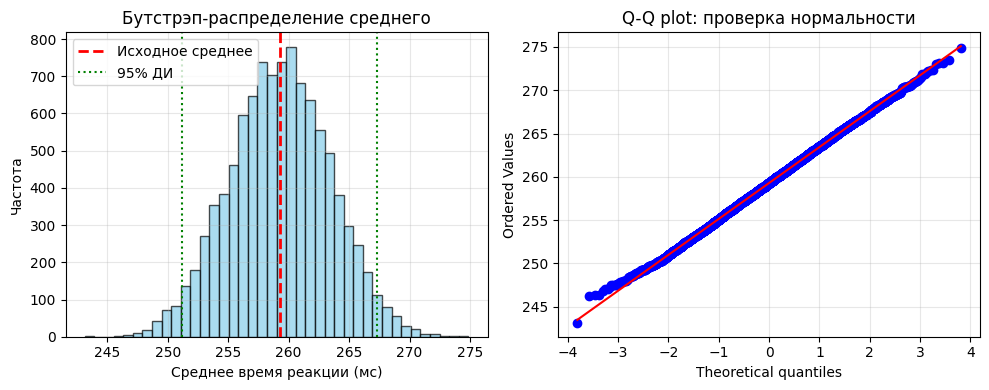

💡 Вывод: Бутстрэп позволяет оценить неопределённость
   статистики без предположений о форме распределения! 🎯


In [ ]:
print("🔄 ТЕМА: Бутстрэп-метод для оценки доверительных интервалов\n")

# Исходные данные: время реакции (мс)
np.random.seed(42)
reaction_times = np.array([245, 267, 234, 289, 256, 278, 241, 263, 252, 271,
                          238, 265, 249, 283, 258])  # n = 15

sample_mean = reaction_times.mean()
sample_std = reaction_times.std(ddof=1)
print(f"📊 Исходная выборка (n={len(reaction_times)}):")
print(f"   Среднее: {sample_mean:.2f} мс, std: {sample_std:.2f} мс\n")

# 🔁 Бутстрэп: многократная ресэмплинг с возвращением
n_bootstrap = 10_000
bootstrap_means = np.zeros(n_bootstrap)

for i in range(n_bootstrap):
    # Ресэмплинг с возвращением (bootstrap sample)
    resample = np.random.choice(reaction_times, size=len(reaction_times), replace=True)
    bootstrap_means[i] = resample.mean()

# 📊 95% доверительный интервал
ci_lower = np.percentile(bootstrap_means, 2.5)
ci_upper = np.percentile(bootstrap_means, 97.5)
bootstrap_std = bootstrap_means.std()

print(f"🔁 Бутстрэп-результаты ({n_bootstrap:,} итераций):")
print(f"   Среднее бутстрэп-распределения: {bootstrap_means.mean():.2f} мс")
print(f"   Стандартная ошибка (bootstrap SE): {bootstrap_std:.2f} мс")
print(f"   95% ДИ: [{ci_lower:.2f}, {ci_upper:.2f}] мс\n")

# 📈 Визуализация бутстрэп-распределения
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(bootstrap_means, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label='Исходное среднее')
plt.axvline(ci_lower, color='green', linestyle=':', label='95% ДИ')
plt.axvline(ci_upper, color='green', linestyle=':')
plt.xlabel('Среднее время реакции (мс)')
plt.ylabel('Частота')
plt.title('Бутстрэп-распределение среднего')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
# Q-Q plot для проверки нормальности
from scipy import stats
stats.probplot(bootstrap_means, dist="norm", plot=plt)
plt.title('Q-Q plot: проверка нормальности')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Вывод: Бутстрэп позволяет оценить неопределённость")
print("   статистики без предположений о форме распределения! 🎯")

## 📊 Краткий обзор Matplotlib

Matplotlib — одна из основных библиотека визуализации в Python.

| Компонент         | Назначение             | Пример использования           |
|-------------------|------------------------|-------------------------------|
| plt.plot()        | Линейные графики       | Сходимость итераций, ошибки    |
| plt.scatter()     | Точки                  | Узлы интерполяции, сетка       |
| plt.contour() / plt.contourf() | Изолинии              | Функции 2 переменных           |
| |
| plt.subplot()     | Несколько графиков     | Сравнение методов              |
| plt.semilogy()    | Логарифмическая шкала | Экспоненциальная сходимость     |

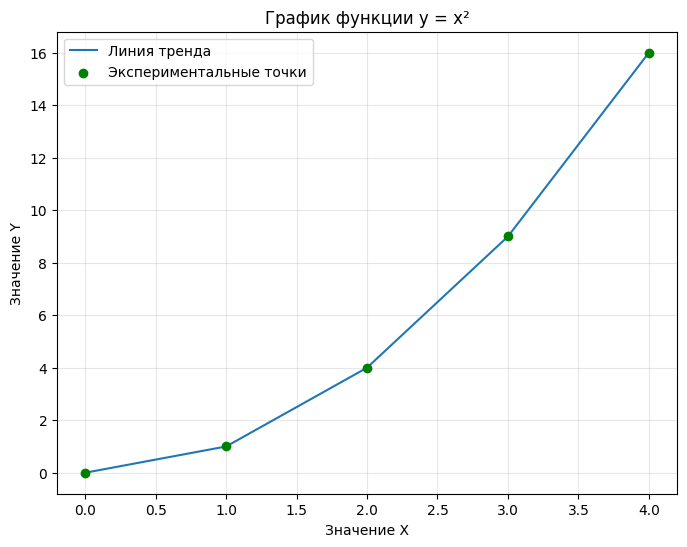

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# 1. ПОДГОТОВКА ДАННЫХ
# ==========================================
# Создаем списки координат.
# В реальном проекте данные могут приходить из файла или вычислений.
x = [0, 1, 2, 3, 4]
y = [0, 1, 4, 9, 16]  # Обратите внимание: это y = x², а не синус!

# ==========================================
# 2. НАСТРОЙКА ВИДА ГРАФИКА
# ==========================================
# figsize=(ширина, высота) - размер окна графика в дюймах
# Это делает график крупнее и удобнее для презентации
plt.figure(figsize=(8, 6))

# ==========================================
# 3. ПОСТРОЕНИЕ ГРАФИКА
# ==========================================
# plt.plot() рисует линию через точки
plt.plot(x, y, label='Линия тренда')

# plt.scatter() рисует отдельные точки поверх линии
# c='green' - цвет точек (color)
# zorder=5 - гарантирует, что точки будут поверх линии
plt.scatter(x, y, c='green', label='Экспериментальные точки', zorder=5)

# ==========================================
# 4. ОФОРМЛЕНИЕ
# ==========================================
plt.xlabel('Значение X')            # Подпись оси X
plt.ylabel('Значение Y')            # Подпись оси Y
plt.title('График функции y = x²')  # Заголовок
plt.grid(True, alpha=0.3)           # Включаем сетку (alpha - прозрачность)
plt.legend()                        # Показываем легенду (подписи к линиям)

# ==========================================
# 5. ВЫВОД ГРАФИКА
# ==========================================
# Эта команда обязательна для отображения окна с графиком
plt.show()

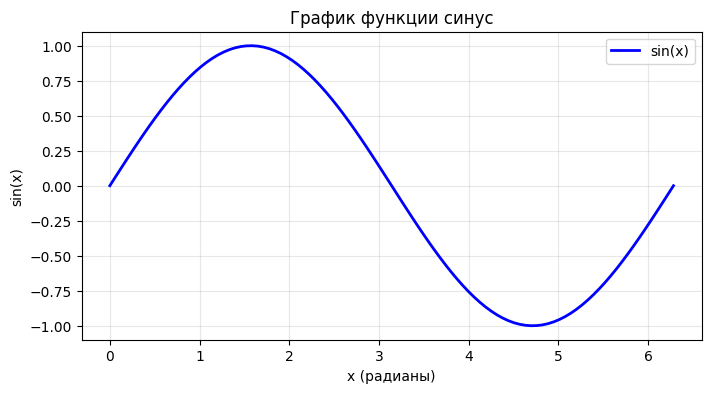

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

# Построение
plt.figure(figsize=(8, 4))          # размер графика 8×4 дюйма
plt.plot(x, y, 'b-', linewidth=2, label='sin(x)')  # синяя линия, толщина 2

# Оформление
plt.xlabel('x (радианы)')           # подпись оси X
plt.ylabel('sin(x)')                # подпись оси Y
plt.title('График функции синус')   # заголовок
plt.grid(True, alpha=0.3)           # сетка с прозрачностью
plt.legend()                        # легенда

plt.show()

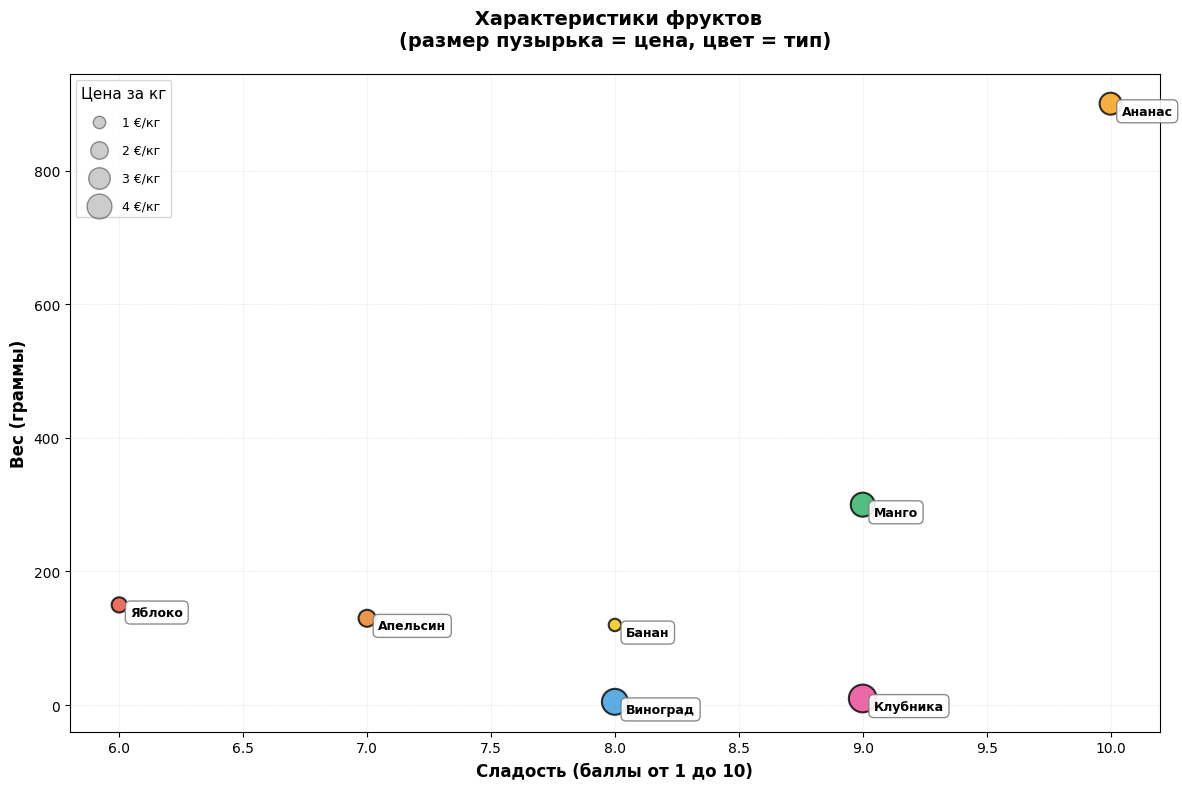

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. ПОДГОТОВКА ДАННЫХ
# ==========================================
# Данные о фруктах: название, сладость, вес, цвет, цена
fruits = ['Яблоко', 'Банан', 'Апельсин', 'Клубника', 'Виноград', 'Ананас', 'Манго']
sweetness = [6, 8, 7, 9, 8, 10, 9]           # Сладость по шкале 1-10
size = [150, 120, 130, 10, 5, 900, 300]      # Вес в граммах
colors = ['#e74c3c', '#f1c40f', '#e67e22', '#e84393', '#3498db', '#f39c12', '#27ae60']
price = [1.2, 0.8, 1.5, 4.0, 3.5, 2.5, 3.0]  # Цена за кг

# ==========================================
# 2. НАСТРОЙКА ВИДА ГРАФИКА
# ==========================================
# figsize=(ширина, высота) — размер окна в дюймах

plt.figure(figsize=(12, 8))

# ==========================================
# 3. ПОСТРОЕНИЕ ПУЗЫРЬКОВОЙ ДИАГРАММЫ
# ==========================================
# s — размер маркера (площадь круга)
# c — цвет маркера
# alpha — прозрачность (0=полностью прозрачный, 1=непрозрачный)
# edgecolors — цвет границы маркера
scatter = plt.scatter(
    sweetness,
    size,
    s=[p * 100 for p in price],   # Размер пропорционален цене (масштабировано для наглядности)
    c=colors,                     # Цвет = тип фрукта
    alpha=0.8,                    # Лёгкая прозрачность для наложения
    edgecolors='black',           # Чёрная обводка для контраста
    linewidth=1.5,
    zorder=3                      # Поверх сетки
)

# ==========================================
# 4. ПОДПИСИ К ТОЧКАМ (АННОТАЦИИ)
# ==========================================
for i, fruit in enumerate(fruits):
    plt.annotate(
        fruit,
        (sweetness[i], size[i]),           # Координаты точки
        xytext=(8, -8),                     # Смещение текста от точки
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9),
        zorder=4                            # Поверх пузырьков
    )

# ==========================================
# 5. ОФОРМЛЕНИЕ ГРАФИКА
# ==========================================
plt.xlabel('Сладость (баллы от 1 до 10)', fontsize=12, fontweight='bold')
plt.ylabel('Вес (граммы)', fontsize=12, fontweight='bold')
plt.title(' Характеристики фруктов\n(размер пузырька = цена, цвет = тип)',
          fontsize=14, pad=20, fontweight='bold')

# Сетка с настройками для лучшей читаемости
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, zorder=1)

# ==========================================
# 6. ЛЕГЕНДА РАЗМЕРОВ (пузырьковая шкала)
# ==========================================
# Создаём фиктивные точки для легенды размеров
legend_sizes = [1, 2, 3, 4]
for p in legend_sizes:
    plt.scatter([], [], s=p*80, c='gray', alpha=0.4, edgecolors='black',
                label=f'{p} €/кг')

# Основная легенда с настройками
plt.legend(
    scatterpoints=1,
    frameon=True,
    labelspacing=1.2,
    title='Цена за кг',
    title_fontsize=11,
    loc='upper left',
    fontsize=9
)

# ==========================================
# 7. ДОПОЛНИТЕЛЬНЫЕ НАСТРОЙКИ
# ==========================================
# Убираем лишние отступы и показываем график
plt.tight_layout()
plt.show()


## Часть 6 🔬 SciPy: Обзор библиотеки для научных вычислений
SciPy — фундаментальная библиотека для научных и инженерных расчётов в Python. Построена поверх NumPy (использует его массивы как основу) и предоставляет готовые алгоритмы для решения типичных задач численных методов.


# 📦 Ключевые модули SciPy и их назначение

| Модуль             | Назначение                           | Типичные задачи                                      |
|--------------------|--------------------------------------|-----------------------------------------------------|
| scipy.optimize     | Оптимизация и поиск корней           | Минимизация функций, решение уравнений, линейное программирование |
| scipy.integrate    | Численное интегрирование              | Вычисление определённых интегралов, решение ОДУ          |
| scipy.interpolate   | Интерполяция                         | Построение гладких кривых через узлы, сплайны           |
| scipy.linalg        | Линейная алгебра                     | Решение СЛАУ, собственные значения, разложения матриц    |
| scipy.stats         | Статистика                           | Распределения, проверка гипотез, описательная статистика |
| scipy.fft          | Быстрое преобразование Фурье          | Анализ сигналов, фильтрация                            |
| scipy.sparse       | Разреженные матрицы                  | Эффективная работа с большими системами (МКЭ, графы)    |

💡 Важно: В отличие от «игрушечных» реализаций в учебных целях, SciPy содержит промышленные алгоритмы (Fortran/C под капотом), протестированные на десятилетиях применения в науке.

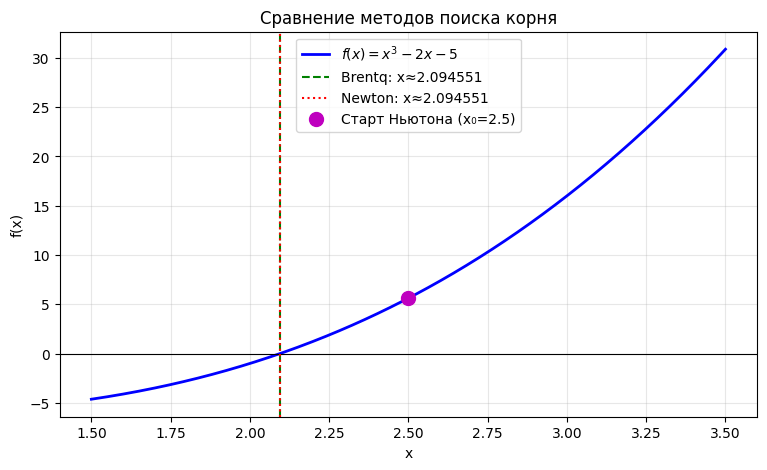

Корень (Brentq): 2.0945514815
Корень (Ньютон): 2.0945514815
Проверка: f(2.094551) = 3.55e-15


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

# Функция и её производная
def f(x): return x**3 - 2*x - 5
def df(x): return 3*x**2 - 2

# Точные корни (для сравнения)
root_brentq = optimize.root_scalar(f, bracket=[2, 3], method='brentq').root
root_newton = optimize.root_scalar(f, x0=2.5, fprime=df, method='newton').root

# Визуализация
x = np.linspace(1.5, 3.5, 400)
plt.figure(figsize=(9, 5))
plt.plot(x, f(x), 'b-', linewidth=2, label='$f(x) = x^3 - 2x - 5$')
plt.axhline(0, color='k', linewidth=0.8)
plt.axvline(root_brentq, color='g', linestyle='--', label=f'Brentq: x≈{root_brentq:.6f}')
plt.axvline(root_newton, color='r', linestyle=':', label=f'Newton: x≈{root_newton:.6f}')
plt.plot(2.5, f(2.5), 'mo', markersize=10, label='Старт Ньютона (x₀=2.5)')
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Сравнение методов поиска корня')
plt.legend()
plt.show()

print(f"Корень (Brentq): {root_brentq:.10f}")
print(f"Корень (Ньютон): {root_newton:.10f}")
print(f"Проверка: f({root_brentq:.6f}) = {f(root_brentq):.2e}")

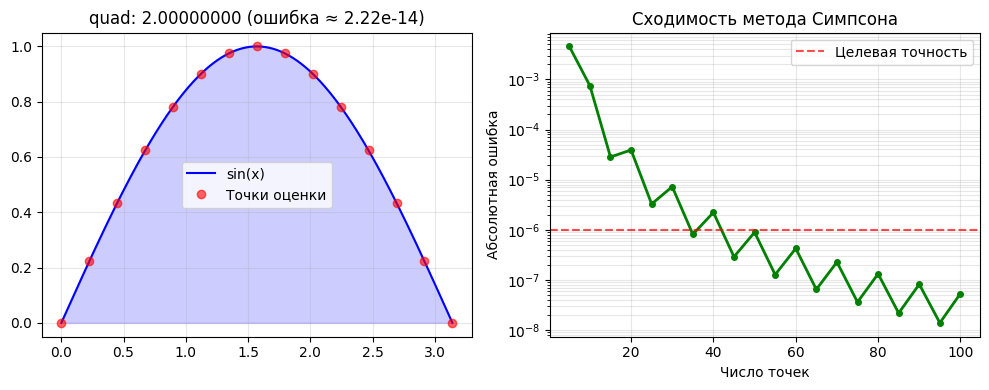

Точное значение:          2.0000000000
quad (Гаусс-Кронрод):     2.0000000000 ± 2.22e-14
Симпсон (101 точка):      2.0000000108


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# Подынтегральная функция
def integrand(x): return np.sin(x)

# Точное значение
exact = 2.0

# Методы интегрирования
result_quad, err_quad = integrate.quad(integrand, 0, np.pi)        # адаптивный Гаусс-Кронрод
result_simpson = integrate.simpson(integrand(np.linspace(0, np.pi, 101)),
                                   dx=np.pi/100)                   # метод Симпсона

# Визуализация: как работает адаптивная квадратура
x_plot = np.linspace(0, np.pi, 300)
y_plot = integrand(x_plot)

plt.figure(figsize=(10, 4))

# Левый график: функция и точки оценки quad
plt.subplot(1, 2, 1)
plt.plot(x_plot, y_plot, 'b-', label='sin(x)')
# Покажем "виртуальные" точки (на самом деле quad адаптивен, но для иллюстрации)
x_sample = np.linspace(0, np.pi, 15)
plt.plot(x_sample, integrand(x_sample), 'ro', alpha=0.6, label='Точки оценки')
plt.fill_between(x_plot, y_plot, alpha=0.2, color='blue')
plt.title(f'quad: {result_quad:.8f} (ошибка ≈ {err_quad:.2e})')
plt.grid(True, alpha=0.3)
plt.legend()

# Правый график: сходимость по числу точек
plt.subplot(1, 2, 2)
n_points = np.arange(5, 101, 5)
errors = []
for n in n_points:
    x = np.linspace(0, np.pi, n)
    approx = integrate.simpson(np.sin(x), x=x)
    errors.append(abs(approx - exact))

plt.semilogy(n_points, errors, 'g-o', linewidth=2, markersize=4)
plt.axhline(y=1e-6, color='r', linestyle='--', alpha=0.7, label='Целевая точность')
plt.xlabel('Число точек')
plt.ylabel('Абсолютная ошибка')
plt.title('Сходимость метода Симпсона')
plt.grid(True, which='both', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Точное значение:          {exact:.10f}")
print(f"quad (Гаусс-Кронрод):     {result_quad:.10f} ± {err_quad:.2e}")
print(f"Симпсон (101 точка):      {result_simpson:.10f}")
